In [586]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sbi import utils as utils
from sbi import analysis as analysis
from sbi.inference.base import infer

from torch.distributions.log_normal import LogNormal
from torch.distributions.normal import Normal

In [571]:
# dimension 1 = M_sat
# dimension 2 = Vz
# dimension 3 = r
num_dim = 3

# uniform distribution from 0.00001 ~ 1
prior_uniform = utils.BoxUniform(low = 0 * torch.ones(num_dim), high = 10 * torch.ones(num_dim))

prior_normal = torch.distributions.MultivariateNormal(5 * torch.ones(num_dim), 1 * torch.eye(num_dim))


# print(prior_uniform.log_prob(0.1))
# print(prior_normal.log_prob(0.1))

In [321]:
# lognormal distribution ~(0.01, 1)
# prior = LogNormal(torch.tensor([0.0]), torch.tensor([1.0]))

In [322]:
# # normal distribution ~(0.5, 0.1)
# prior = Normal(torch.tensor([0.5]), torch.tensor([0.1]))
# prior.log_prob(torch.tensor([0.1]))

In [323]:
# prior = torch.distributions.chi2.Chi2(torch.tensor([1.0]))

In [572]:
def simple_relation(phi1s, M_sat, vz, r, scatter=0.1):

    phi2s = phi1s/M_sat
    phi1s = phi1s + M_sat/vz/r

    phi1s = np.array(phi1s)
    phi2s = np.array(phi2s)
    
    positions = np.concatenate([phi1s,phi2s])
    positions = torch.from_numpy(positions)
    
    return positions + torch.randn_like(positions) * scatter

# print(simple_relation(np.arange(10), 0.1, 0.1))

In [573]:
def simulator(params, n_obs=100, scatter=0.1):
    params = torch.as_tensor(params)
    M_sat = params[0]
    vz = params[1]
    r = params[2]

    # phi1 values evenly spaced
    phi1s = np.arange(n_obs)
    phi1s = torch.tensor(phi1s)

    return simple_relation(phi1s, M_sat, vz, r, scatter)

In [391]:
# x = np.arange(100)
# y = simulator(torch.as_tensor([0.1]))

# plt.plot(x, y-x*10)

In [574]:
posterior = infer(simulator, prior_uniform, "SNPE", num_simulations=1000)


Running 1000 simulations.: 100%|██████████| 1000/1000 [00:00<00:00, 12748.92it/s]


 Neural network successfully converged after 218 epochs.

In [575]:
observation1 = simulator(torch.as_tensor([1,2,9]))
# print(observation1.shape)

observation2= simulator(torch.as_tensor([2,8,5]))

observation3= simulator(torch.as_tensor([5,5,6]))

observation4 = simulator(torch.as_tensor([9,1,1]))

observation5 = simulator(torch.as_tensor([9,9,8]))

In [619]:
posterior_samples_1 = posterior.sample((10,), x=observation1)
print(posterior_samples_1)
print(len(posterior_samples_1[0]))

Drawing 10 posterior samples: 95it [00:00, 6827.60it/s]             

tensor([[0.9851, 8.1879, 4.5791],
        [0.9969, 8.3173, 4.0852],
        [0.9963, 5.5639, 6.9917],
        [0.9603, 3.2963, 7.7352],
        [1.0016, 5.6712, 2.3327],
        [1.0248, 3.6775, 8.0103],
        [0.9970, 6.3104, 3.6944],
        [1.0439, 9.7328, 4.7415],
        [0.9965, 2.8043, 8.7190],
        [1.0372, 7.2401, 6.3552]])
3


In [631]:
posterior_samples_2 = posterior.sample((10000,), x=observation2)
print(np.array(posterior_samples_2[:,0]))

Drawing 10000 posterior samples: 11580it [00:00, 19724.23it/s]                          

[2.0409262 2.1109736 2.0131943 ... 2.0315275 2.0279295 2.0258536]


In [578]:
posterior_samples_3 = posterior.sample((10000,), x=observation3)

Drawing 10000 posterior samples: 11118it [00:00, 25341.67it/s]                          


In [579]:
posterior_samples_4 = posterior.sample((10000,), x=observation4)

Drawing 10000 posterior samples: 11613it [00:00, 20528.69it/s]                          


In [580]:
posterior_samples_5 = posterior.sample((10000,), x=observation5)

Drawing 10000 posterior samples: 10017it [00:00, 16284.54it/s]                          


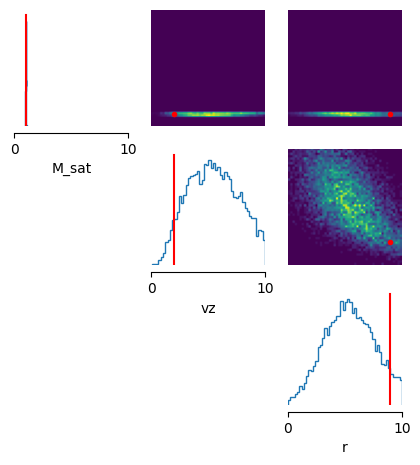

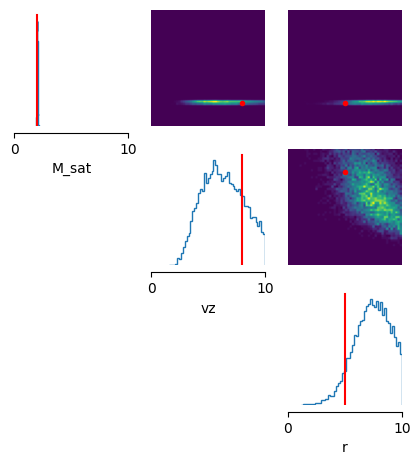

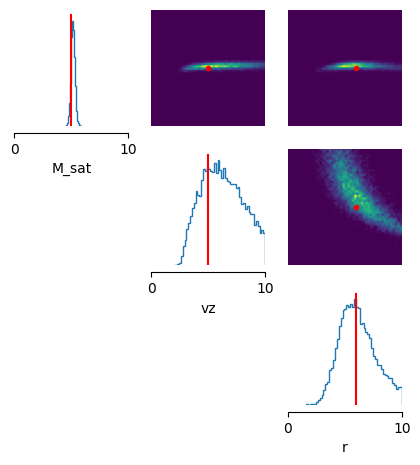

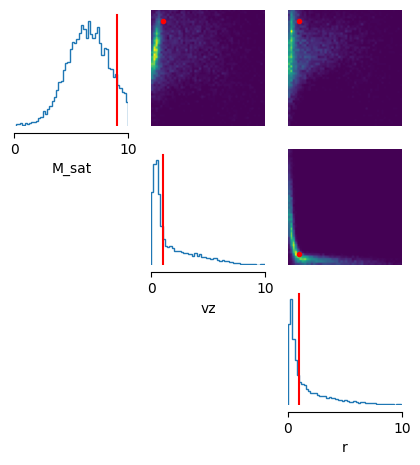

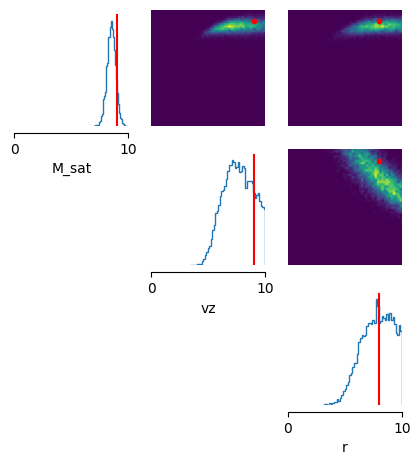

In [584]:
# plot posterior samples
_ = analysis.pairplot(
    posterior_samples_1, limits=[[0,10], [0,10],[0,10]],
    ticks=[[0,10], [0,10],[0,10]],
    figsize=(5, 5),
    points=np.array([1,2,9]),
    points_offdiag={"markersize": 6},
    points_colors="r",
    labels=["M_sat","vz","r"]
)

_ = analysis.pairplot(
    posterior_samples_2, limits=[[0,10], [0,10],[0,10]],
    ticks=[[0,10], [0,10],[0,10]],
    figsize=(5, 5),
    points=np.array([2,8,5]),
    points_offdiag={"markersize": 6},
    points_colors="r",
    labels=["M_sat","vz","r"]
)

_ = analysis.pairplot(
    posterior_samples_3, limits=[[0,10], [0,10],[0,10]],
    ticks=[[0,10], [0,10],[0,10]],
    figsize=(5, 5),
    points=np.array([5,5,6]),
    points_offdiag={"markersize": 6},
    points_colors="r",
    labels=["M_sat","vz","r"]
)

_ = analysis.pairplot(
    posterior_samples_4, limits=[[0,10], [0,10],[0,10]],
    ticks=[[0,10], [0,10],[0,10]],
    figsize=(5, 5),
    points=np.array([9,1,1]),
    points_offdiag={"markersize": 6},
    points_colors="r",
    labels=["M_sat","vz","r"]
)

_ = analysis.pairplot(
    posterior_samples_5, limits=[[0,10], [0,10],[0,10]],
    ticks=[[0,10], [0,10],[0,10]],
    figsize=(5, 5),
    points=np.array([9,9,8]),
    points_offdiag={"markersize": 6},
    points_colors="r",
    labels=["M_sat","vz","r"]
)

draw 100 medians

In [600]:
import numpy as np
from rotation_matrix import obs_from_pos6d
import matplotlib.pyplot as plt

import scipy

R_phi12_radec = np.array([[0.83697865, 0.29481904, -0.4610298], 
                          [0.51616778, -0.70514011, 0.4861566], 
                          [0.18176238, 0.64487142, 0.74236331]])

In [602]:
def draw_medians_scipy(phi1s, phi2s, bins = 100):
    bin_medians, bin_edges, bin_number = scipy.stats.binned_statistic(phi1s, phi2s, statistic='median', bins = bins)
    plt.hlines(bin_medians, bin_edges[:-1], bin_edges[1:], color = 'orange', label='binned statistic of data')



In [612]:
# phi1s, phi2s np.array 
def draw_medians(phi1s,phi2s,bins = 100):
    bin_width = len(phi1s)/bins
    phi1_medians = np.array([])
    phi2_medians = np.array([])

    for _ in range(bins):
        phi1s_in_range = np.array([])
        phi2s_in_range = np.array([])
        number_particles = 0
        while number_particles < bin_width:
            number_particles += 1

            phi1_to_add = np.min(phi1s)
            phi1_index = np.where((phi1s == phi1_to_add))
            phi2_to_add = phi2s[phi1_index[0]]

            phi1s_in_range = np.append(phi1s_in_range, [phi1_to_add])
            phi2s_in_range = np.append(phi2s_in_range, [phi2_to_add])

            #print(phi1s_in_range)

            phi1s = np.delete(phi1s, [phi1_index])
            phi2s = np.delete(phi2s, [phi1_index])
        
        phi1_medians = np.append(phi1_medians, [np.median(phi1s_in_range)])
        phi2_medians = np.append(phi2_medians, [np.median(phi2s_in_range)])
    
    plt.scatter(phi1_medians,phi2_medians, s=5,label='binned statistic of data')

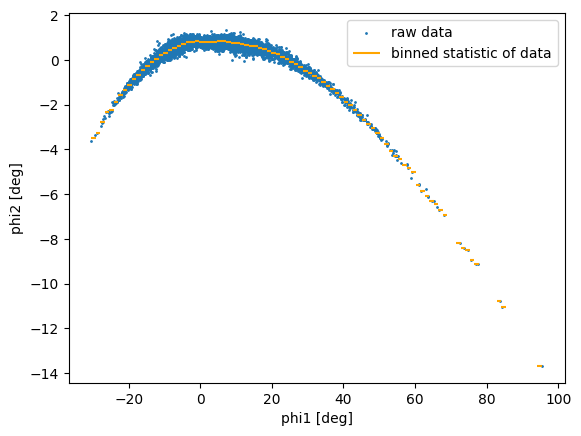

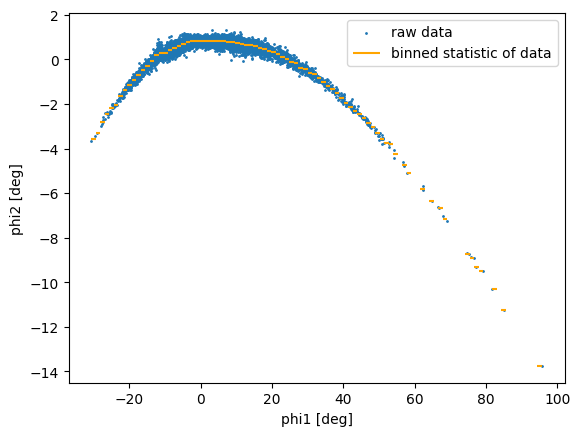

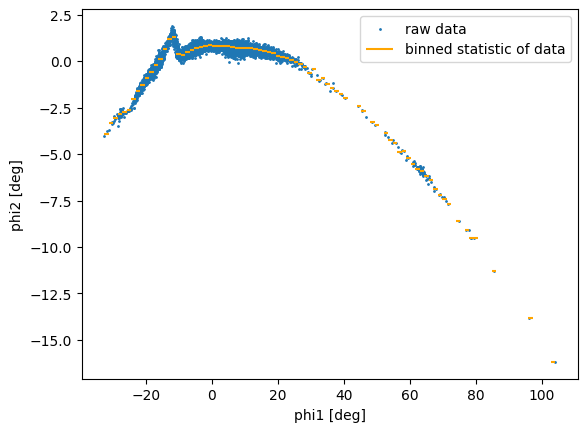

In [638]:
for i in range(3):
    data = np.genfromtxt(f'final_stream/final_stream_{i}.txt')
    phi1,phi2,dist,pm1,pm2,vr = obs_from_pos6d(data[:,:3],data[:,3:6],R_phi12_radec)

    plt.scatter(phi1,phi2,s =1, label='raw data')
    draw_medians_scipy(phi1, phi2, 100)

    plt.xlabel("phi1 [deg]")
    plt.ylabel("phi2 [deg]")
    plt.legend()
    plt.show()

with constant perturbation strength lines

/Users/rutongpei/opt/anaconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:17: RuntimeWarning: divide by zero encountered in true_divide
  app.launch_new_instance()
/Users/rutongpei/opt/anaconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:21: RuntimeWarning: divide by zero encountered in true_divide
/Users/rutongpei/opt/anaconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:24: RuntimeWarning: divide by zero encountered in true_divide
/Users/rutongpei/opt/anaconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:27: RuntimeWarning: divide by zero encountered in true_divide


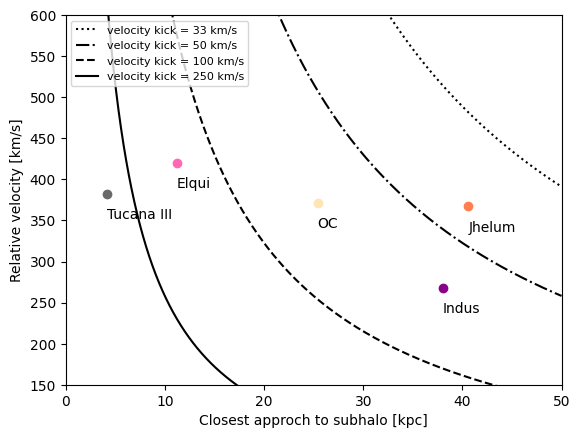

6.67e-11 2.985e+41 3.086e+20 33000.0


In [336]:
G=6.67e-11
M= 15 # mass of subhalo in 1e10 Msun
#b= impact parameter in kpc
#w= relative velocity in km/s

#delta_v in km/s
delta_v1= 33
delta_v2= 50
delta_v3= 100
delta_v4= 250

# x axis: cloest approach to subhalo, i.e. impact parameter b
# y axis: relative velocity at cloest approach, w


b = np.arange(0.0, 50.0, 0.01)
w1 = G*(M*1.99e40)/(b*3.086e19)/(delta_v1*1e3)/1e3
plt.plot(b,w1, label=f'velocity kick = {delta_v1} km/s', linestyle='dotted', color='black')


w2 = G*(M*1.99e40)/(b*3.086e19)/(delta_v2*1e3)/1e3
_ = plt.plot(b,w2, label=f'velocity kick = {delta_v2} km/s', linestyle='-.', color='black')

w3 = G*(M*1.99e40)/(b*3.086e19)/(delta_v3*1e3)/1e3
_ = plt.plot(b,w3, label=f'velocity kick = {delta_v3} km/s', linestyle='--', color='black')

w4 = G*(M*1.99e40)/(b*3.086e19)/(delta_v4*1e3)/1e3
_ = plt.plot(b,w4, label=f'velocity kick = {delta_v4} km/s', color='black')

plt.legend(prop={'size':8})
plt.xlim(0, 50)
plt.ylim(150, 600)
plt.xlabel("Closest approch to subhalo [kpc]")
plt.ylabel("Relative velocity [km/s]")


# stream models as dots
x=[4.2, 11.2, 25.4, 40.6, 38]
y=[382, 420, 371, 367, 268]
streams=['Tucana III', 'Elqui', 'OC', 'Jhelum', 'Indus']
colors=['dimgray', 'hotpink','moccasin','coral','darkmagenta']
for i in range(5):
    plt.plot(x[i],y[i],'o', color=colors[i])
    plt.text(x[i],y[i]-30, streams[i])

plt.show()
print(G, (M*1.99e40), (10*3.086e19), (delta_v1*1e3))